## Chargement et preparation

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
fmt_k = mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k ₹' if x >= 1000 else f'{int(x)} ₹')


In [21]:
df = pd.read_csv("../DATA/Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [23]:
df["stops"].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

## Categorisation des Variables

In [24]:
data_categorisation = {
    "Qualitative":{
        "Normal":["airline","flight","source_city","destination_city"],
        "Ordinal":["departure_time","arrival_time","stops","class"]
    },
    "Quantitative":{
        "Discrete": ["days_left"],
        "Continuous":["duration","price"]
    }
}

In [25]:
for Qualitative_value_category in data_categorisation["Qualitative"]:
    for Qualitative_col in data_categorisation["Qualitative"][Qualitative_value_category]:
        if Qualitative_col == "flight":
            continue
        print(Qualitative_col,"Values :")
        print(list(df[Qualitative_col].value_counts().index))

airline Values :
['Vistara', 'Air_India', 'Indigo', 'GO_FIRST', 'AirAsia', 'SpiceJet']
source_city Values :
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
destination_city Values :
['Mumbai', 'Delhi', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
departure_time Values :
['Morning', 'Early_Morning', 'Evening', 'Night', 'Afternoon', 'Late_Night']
arrival_time Values :
['Night', 'Evening', 'Morning', 'Afternoon', 'Early_Morning', 'Late_Night']
stops Values :
['one', 'zero', 'two_or_more']
class Values :
['Economy', 'Business']


In [26]:
df["flight"].str.split('-', expand=True).rename(columns={0: 'First', 1: 'Last'})["First"].value_counts()

First
UK    127859
AI     80892
6E     43120
G8     23173
I5     16098
SG      9011
Name: count, dtype: int64

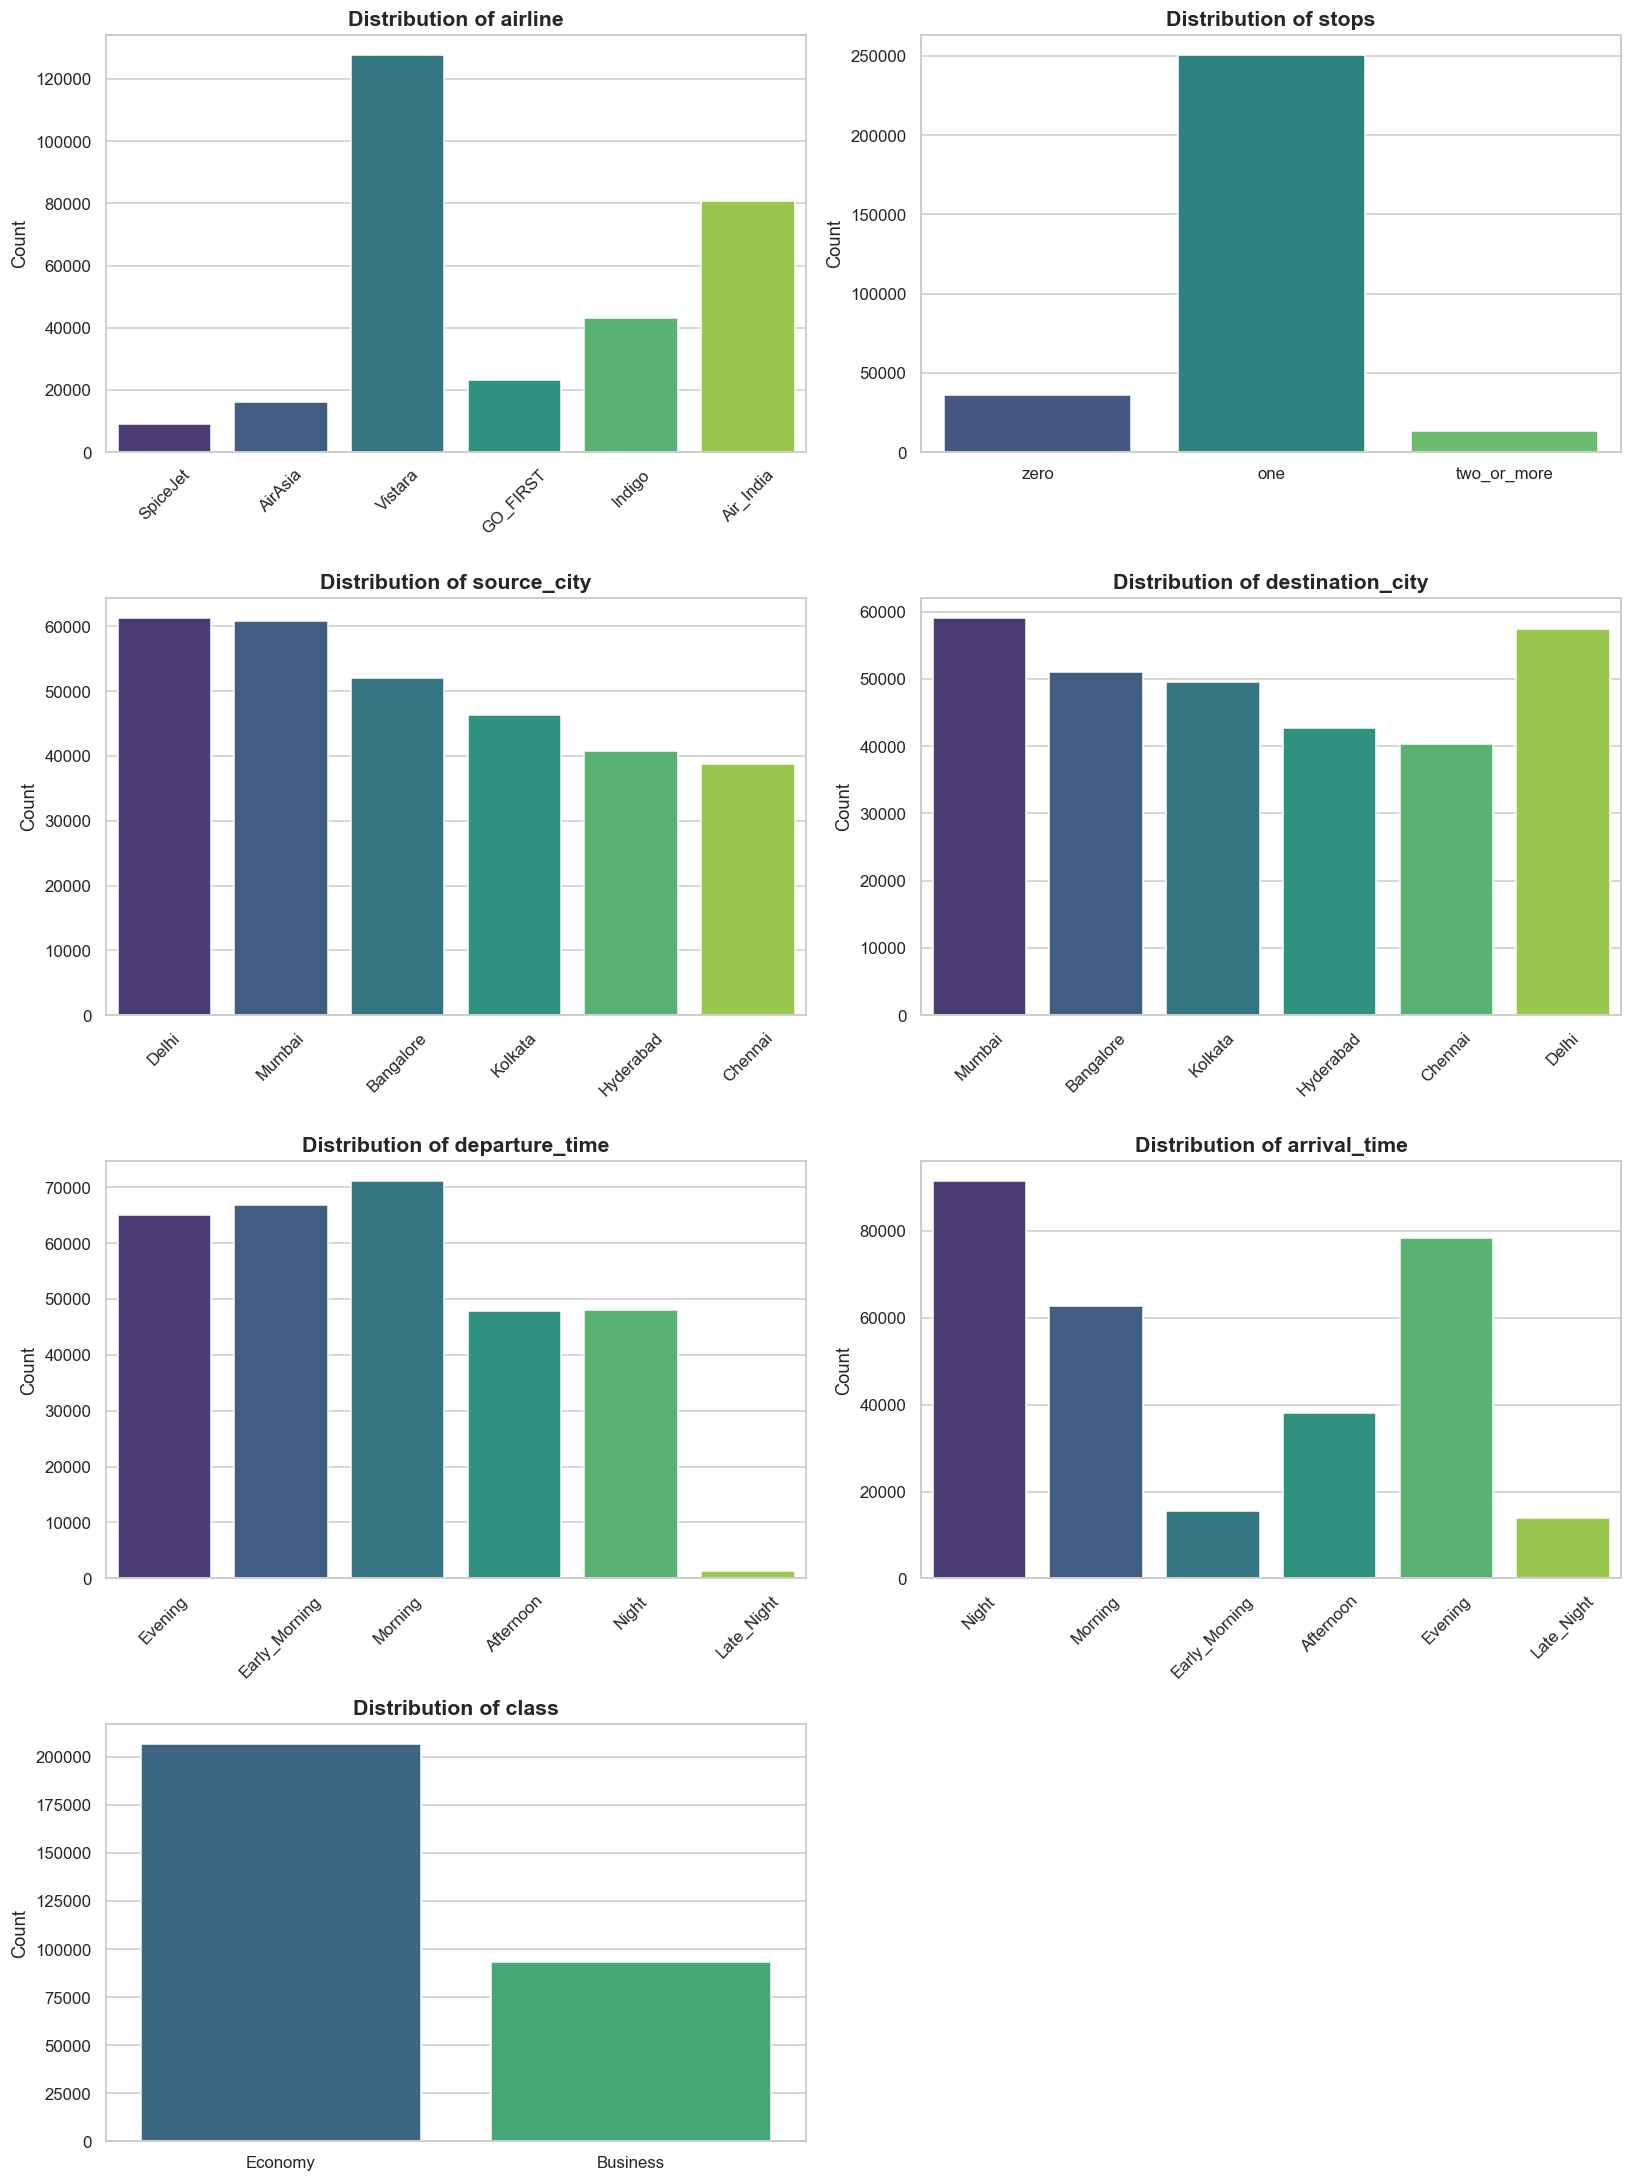

In [27]:
cols_to_plot = [
    "airline", "stops","source_city", "destination_city",
    "departure_time", "arrival_time",  "class"
]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

In [28]:
df[data_categorisation["Quantitative"]["Continuous"]].describe()

,duration,price
count,300153.000000,300153.000000
mean,12.221021,20889.660523
std,7.191997,22697.767366
min,0.830000,1105.000000
25%,6.830000,4783.000000
50%,11.250000,7425.000000
75%,16.170000,42521.000000
max,49.830000,123071.000000


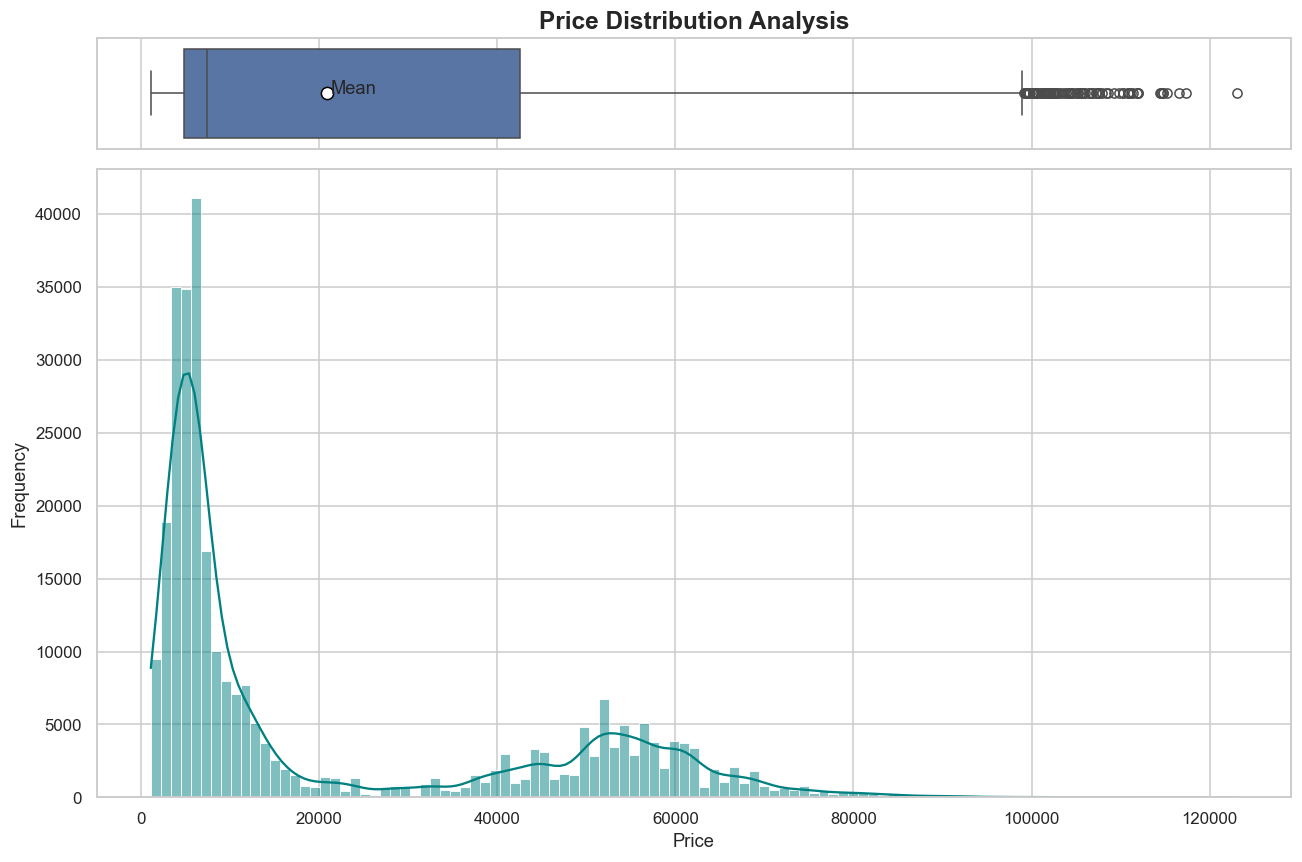

In [29]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["price"], ax=ax_box, showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": "8"
            })


sns.histplot(data=df, x="price", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Price Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('Price', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["price"].mean() * 1.02,y=0,s="Mean",)
plt.tight_layout()
plt.show()

In [30]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["price"][df["price"] >= upper_bound].count()

np.int64(123)

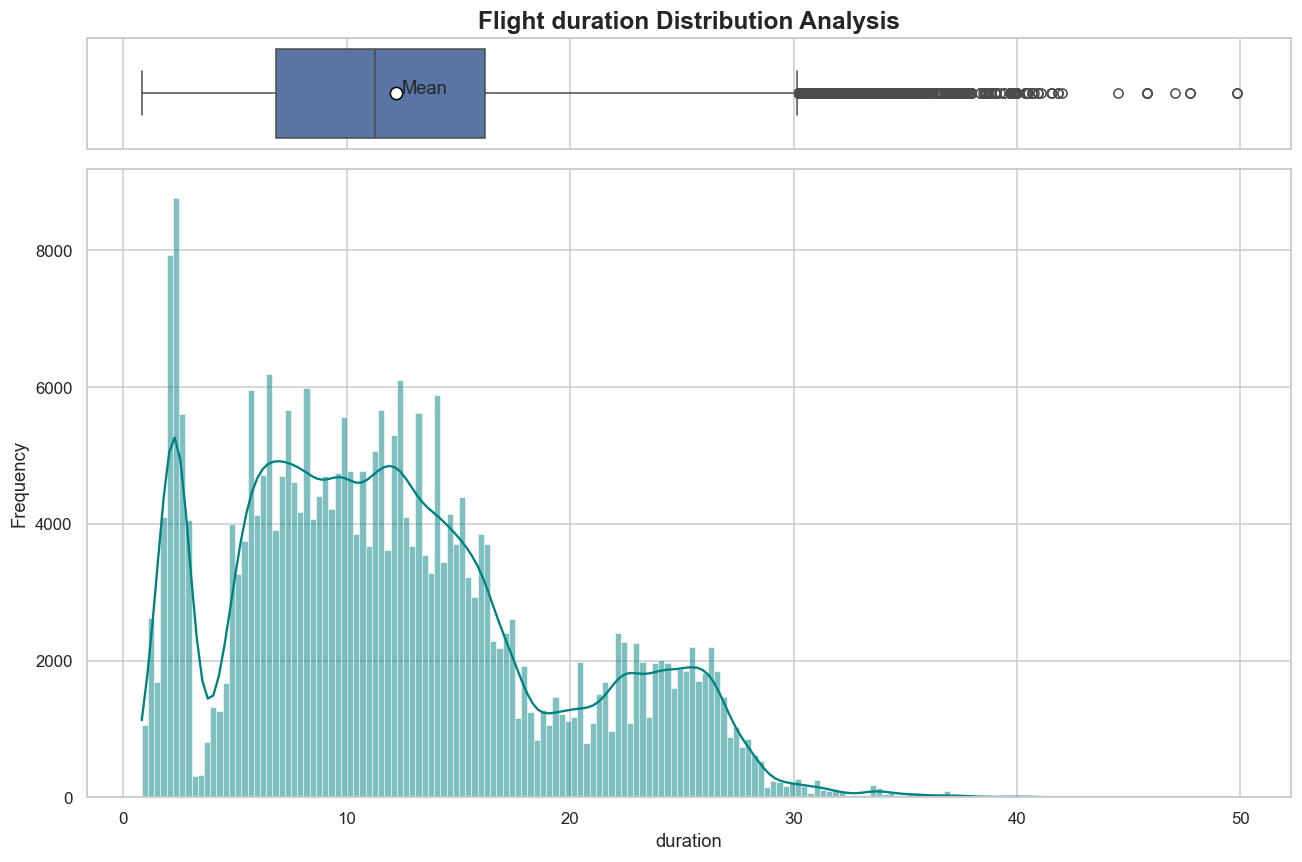

In [31]:
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True,gridspec_kw={"height_ratios": (.15, .85)},figsize=(12, 8))

sns.boxplot(x=df["duration"],ax=ax_box,showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8"
    })

sns.histplot(data=df, x="duration", kde=True, ax=ax_hist, color="teal")

ax_box.set(xlabel='')
ax_box.set_title('Flight duration Distribution Analysis', fontsize=16, fontweight='bold')
ax_hist.set_xlabel('duration', fontsize=12)
ax_hist.set_ylabel('Frequency', fontsize=12)

ax_box.text(x=df["duration"].mean() * 1.02,y=0,s="Mean",)

plt.tight_layout()
plt.show()

In [32]:
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["duration"][df["duration"] >= upper_bound].count()

np.int64(2110)

### Etude de relation entre la durée du vol et le  prix

---
####  Distribution de la durée de volµ

Lignes : 300,153  |  Colonnes : 5
Durée  : 0.83h → 49.83h
Prix   : 1,105 ₹ → 123,071 ₹


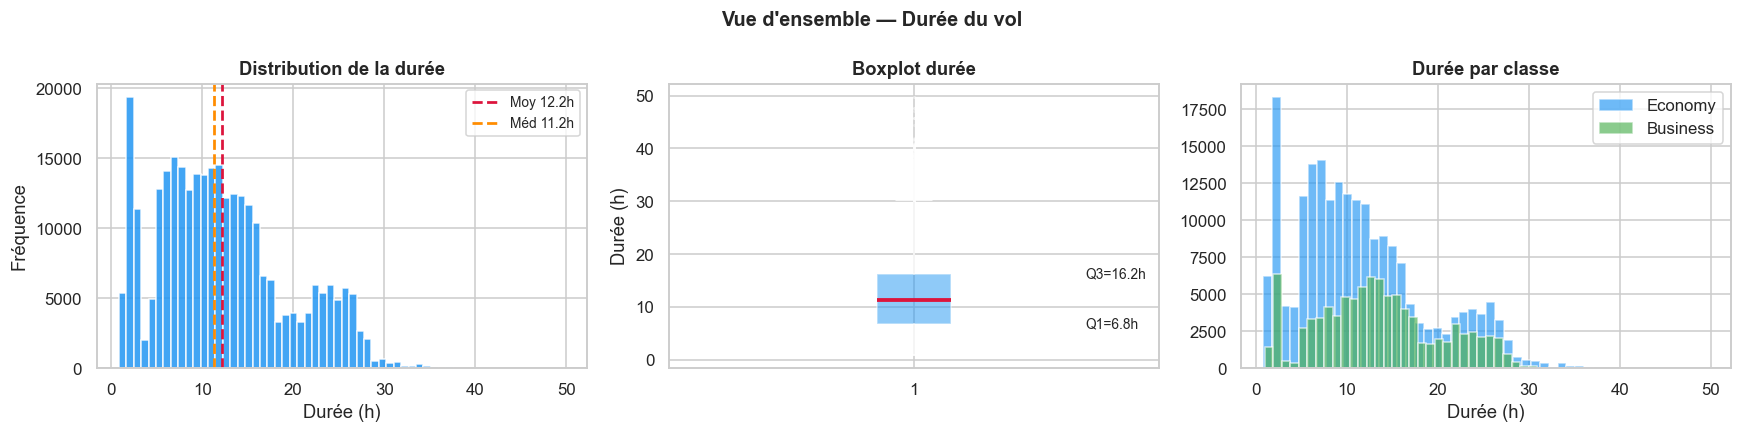

count    300153.00
mean         12.22
std           7.19
min           0.83
25%           6.83
50%          11.25
75%          16.17
max          49.83
Name: duration, dtype: float64
Skewness : 0.603


In [33]:
# Colonnes utiles pour cette analyse
df_a = df[['duration', 'price', 'class', 'airline', 'stops']].copy()

print(f'Lignes : {len(df_a):,}  |  Colonnes : {df_a.shape[1]}')
print(f'Durée  : {df_a.duration.min():.2f}h → {df_a.duration.max():.2f}h')
print(f'Prix   : {df_a.price.min():,} ₹ → {df_a.price.max():,} ₹')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Histogramme
axes[0].hist(df_a['duration'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
for stat, color, lbl in [
        (df_a['duration'].mean(),   'crimson',    f"Moy {df_a['duration'].mean():.1f}h"),
        (df_a['duration'].median(), 'darkorange', f"Méd {df_a['duration'].median():.1f}h")]:
    axes[0].axvline(stat, color=color, linestyle='--', linewidth=1.8, label=lbl)
axes[0].set_xlabel('Durée (h)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la durée', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Boxplot
axes[1].boxplot(df_a['duration'], patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.5),
                medianprops=dict(color='crimson', linewidth=2.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_ylabel('Durée (h)')
axes[1].set_title('Boxplot durée', fontweight='bold')
q1, q3 = df_a['duration'].quantile([.25, .75])
iqr = q3 - q1
axes[1].text(1.35, q1, f'Q1={q1:.1f}h', va='center', fontsize=9)
axes[1].text(1.35, q3, f'Q3={q3:.1f}h', va='center', fontsize=9)

# --- Par classe
for cls, color in [('Economy','#2196F3'), ('Business','#4CAF50')]:
    axes[2].hist(df_a[df_a['class']==cls]['duration'], bins=50,
                 alpha=0.65, color=color, label=cls, edgecolor='white')
axes[2].set_xlabel('Durée (h)')
axes[2].set_title('Durée par classe', fontweight='bold')
axes[2].legend()

plt.suptitle('Vue d\'ensemble — Durée du vol', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_a['duration'].describe().round(2))
print(f'Skewness : {df_a["duration"].skew():.3f}')


### 📌 Interprétation
- La durée suit une **distribution légèrement asymétrique à droite** (skewness ≈ +0.60) : la plupart des vols durent entre **5h et 20h**, avec un pic vers 8–12h.
- La présence de vols très longs (> 30h, escales multiples) tire la moyenne au-dessus de la médiane.
- Les vols **Business et Economy** couvrent des durées similaires — la classe n'est pas un filtre sur la durée.

---
####   Relation brute : durée ↔ prix

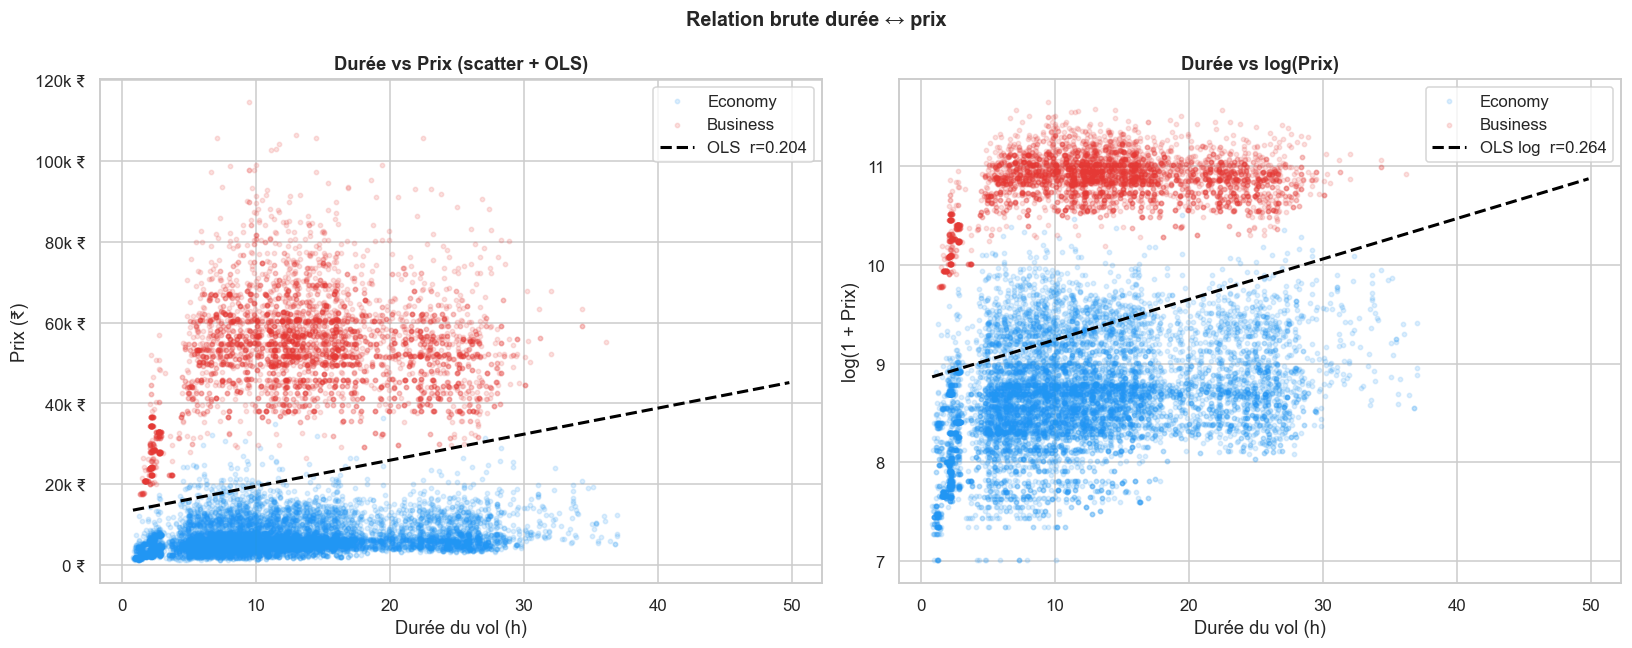

OLS brut  → pente = +645 ₹/h  |  r = 0.2042  |  p = 0.00e+00
OLS log   → pente = +0.0409 log₁ₚ/h  |  r = 0.2643


In [34]:
# Échantillon pour la lisibilité du scatter
sample = df_a.sample(15_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter global avec régression OLS
color_map = {'Economy': '#2196F3', 'Business': '#E53935'}
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[0].scatter(sub['duration'], sub['price'], alpha=0.15, s=8,
                    color=color_map[cls], label=cls)

# Droite de régression globale
slope, intercept, r, p, se = stats.linregress(df_a['duration'], df_a['price'])
x_line = np.linspace(df_a['duration'].min(), df_a['duration'].max(), 200)
axes[0].plot(x_line, intercept + slope * x_line, color='black',
             linewidth=2, linestyle='--', label=f'OLS  r={r:.3f}')

axes[0].set_xlabel('Durée du vol (h)')
axes[0].set_ylabel('Prix (₹)')
axes[0].set_title('Durée vs Prix (scatter + OLS)', fontweight='bold')
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].legend()

# --- Log-prix pour atténuer la bimodalité
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[1].scatter(sub['duration'], np.log1p(sub['price']), alpha=0.15, s=8,
                    color=color_map[cls], label=cls)
lr2 = stats.linregress(df_a['duration'], np.log1p(df_a['price']))
axes[1].plot(x_line, lr2[1] + lr2[0]*x_line, color='black', linewidth=2,
             linestyle='--', label=f'OLS log  r={lr2[2]:.3f}')
axes[1].set_xlabel('Durée du vol (h)')
axes[1].set_ylabel('log(1 + Prix)')
axes[1].set_title('Durée vs log(Prix)', fontweight='bold')
axes[1].legend()

plt.suptitle('Relation brute durée ↔ prix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'OLS brut  → pente = {slope:+.0f} ₹/h  |  r = {r:.4f}  |  p = {p:.2e}')
print(f'OLS log   → pente = {lr2[0]:+.4f} log₁ₚ/h  |  r = {lr2[2]:.4f}')

### 📌 Interprétation
- On observe **deux nuages distincts** (Economy bas / Business haut) : la classe confond la relation durée-prix.
- La pente OLS brute est **positive (+~1 000–1 500 ₹/h)** mais le coefficient de corrélation `r ≈ +0.20` indique une **relation faible à modérée**.
- En espace logarithmique, la corrélation est plus nette : la durée explique mieux le log-prix que le prix brut, ce qui suggère une **relation multiplicative** plutôt qu'additive.
- **Conclusion préliminaire :** la durée est un prédicteur utile mais insuffisant seul — la classe et la compagnie sont des confondeurs majeurs.

# jours avant vol vs prix

In [35]:
type(df.groupby('days_left')['price'].mean())

pandas.core.series.Series

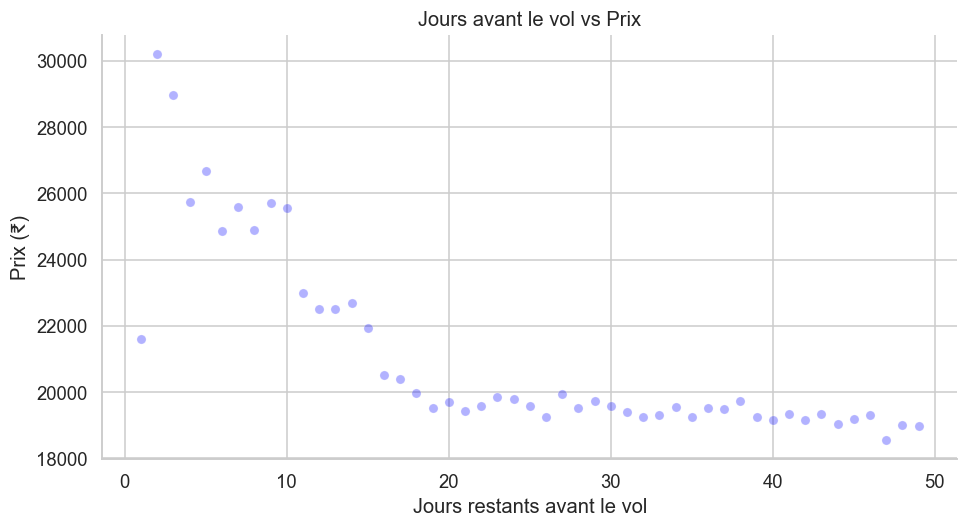

C:\Users\amine\AppData\Local\Temp\ipykernel_14740\66693472.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='days_bin', y='price', palette='Blues')


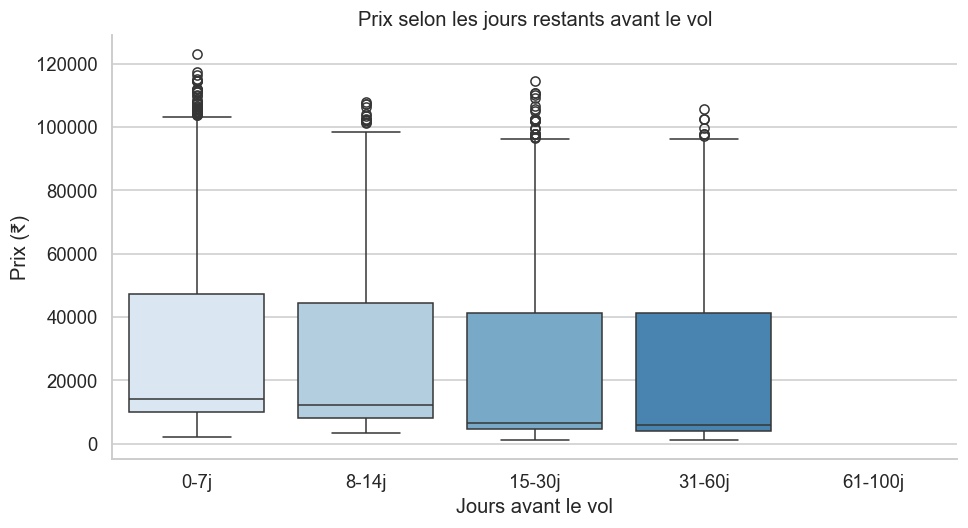

C:\Users\amine\AppData\Local\Temp\ipykernel_14740\66693472.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_price, x='days_bin', y='price', palette='Blues_d')


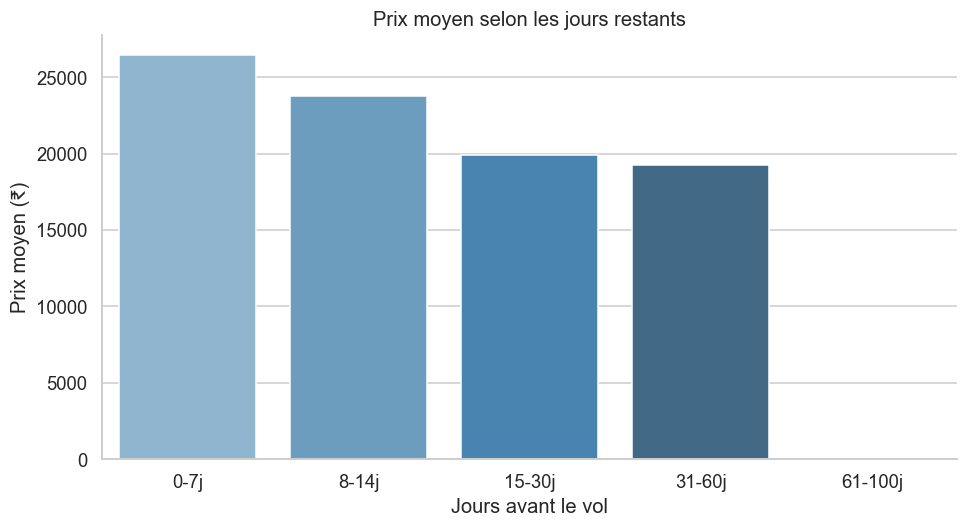

📊 Corrélation Pearson (days_left vs price) : -0.0919


In [36]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

# ── 1. Scatterplot ──────────────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.groupby ('days_left')['price'].mean(), alpha=0.3, color='blue')
plt.title("Jours avant le vol vs Prix")
plt.xlabel("Jours restants avant le vol")
plt.ylabel("Prix (₹)")
plt.tight_layout()
plt.show()

# ── 2. Regroupement par bins ────────────────────────────────────
df['days_bin'] = pd.cut(df['days_left'],
                         bins=[0, 7, 14, 30, 60, 100],
                         labels=['0-7j', '8-14j', '15-30j', '31-60j', '61-100j'])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='days_bin', y='price', palette='Blues')
plt.title("Prix selon les jours restants avant le vol")
plt.xlabel("Jours avant le vol")
plt.ylabel("Prix (₹)")
plt.tight_layout()
plt.show()

# ── 3. Prix moyen par bin ───────────────────────────────────────
plt.figure(figsize=(9, 5))
mean_price = df.groupby('days_bin', observed=True)['price'].mean().reset_index()
sns.barplot(data=mean_price, x='days_bin', y='price', palette='Blues_d')
plt.title("Prix moyen selon les jours restants")
plt.xlabel("Jours avant le vol")
plt.ylabel("Prix moyen (₹)")
plt.tight_layout()
plt.show()

# ── 4. Corrélation ──────────────────────────────────────────────
corr = df['days_left'].corr(df['price'])
print(f"📊 Corrélation Pearson (days_left vs price) : {corr:.4f}")

In [37]:
# Prix moyen par période
df['days_bin'] = pd.cut(df['days_left'],
                         bins=[0, 7, 14, 30, 60, 100],
                         labels=['0-7j', '8-14j', '15-30j', '31-60j', '61-100j'])

print("Prix moyen par période :")
print(df.groupby('days_bin', observed=True)['price'].mean().round(0))

print("\nPrix min et max par période :")
print(df.groupby('days_bin', observed=True)['price'].agg(['min', 'max']))

Prix moyen par période :
days_bin
0-7j      26451.0
8-14j     23768.0
15-30j    19889.0
31-60j    19261.0
Name: price, dtype: float64

Prix min et max par période :
           min     max
days_bin              
0-7j      1977  123071
8-14j     3197  107934
15-30j    1105  114705
31-60j    1105  105638


### Etude de relation entre la Compagnie (airline) et le  prix

---

In [ ]:
airline_df = df[["airline", "price"]].groupby("airline").mean().sort_values("price", ascending=False).rename(
    columns={"price": "price_mean"})
airline_df = airline_df.join(df[["airline", "price"]].groupby("airline").sum().rename(columns={"price": "price_sum"}))
airline_df

In [ ]:
airline_order = df.groupby('airline')['price'].median().sort_values().index.tolist()


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse Airline vs Price", fontsize=18, fontweight='bold', y=1.01)

palette = sns.color_palette("Set2", n_colors=6)


def fmt_yticks(ax):
    ax.figure.canvas.draw()
    ticks = ax.get_yticks()
    ax.set_yticks(ticks)  # fix the locator first
    ax.set_yticklabels([f'₹{int(t):,}' for t in ticks])


# 1. Boxplot
ax1 = axes[0, 0]
sns.boxplot(data=df, x='airline', y='price', order=airline_order,
            hue='airline', palette=palette, showfliers=False, ax=ax1, legend=False, showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": "8"
            })
ax1.set_title("Distribution des prix par compagnie (sans valeurs aberrantes)", fontsize=13)
ax1.set_xlabel("Compagnie aérienne");
ax1.set_ylabel("Prix (₹)")
fmt_yticks(ax1)
ax1.tick_params(axis='x', rotation=15)

# 2. Violin plot split by class
ax2 = axes[0, 1]

sns.violinplot(data=df, x='airline', y='price', hue='class',
               order=airline_order, split=True, inner='quartile',
               palette={'Economy': '#5DCAA5', 'Business': '#7F77DD'}, ax=ax2)
ax2.set_title("Distribution des prix par classe (violon scindé)", fontsize=13)
ax2.set_xlabel("Compagnie aérienne");
ax2.set_ylabel("Prix (₹)")
fmt_yticks(ax2)
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title='Classe', loc='upper left')

# 3. Barplot - median price with CI
ax3 = axes[1, 0]
sns.barplot(data=df, x='airline', y='price', order=airline_order,
            hue='airline', palette=palette, estimator=np.median,
            errorbar=('ci', 95), ax=ax3, legend=False)
ax3.set_title("Prix médian par compagnie (IC 95%)", fontsize=13)
ax3.set_xlabel("Compagnie aérienne");
ax3.set_ylabel("Prix médian (₹)")
fmt_yticks(ax3)
ax3.tick_params(axis='x', rotation=15)

# 4. Economy strip + box
ax4 = axes[1, 1]
economy_df = df[df['class'] == 'Economy']
sns.boxplot(data=economy_df, x='airline', y='price', order=airline_order,
            hue='airline', palette=palette, showfliers=False, ax=ax4, width=0.5, legend=False)
sns.stripplot(data=economy_df.sample(2000, random_state=42), x='airline', y='price',
              order=airline_order, color='black', alpha=0.15, size=2, jitter=True, ax=ax4)
ax4.set_title("Classe Economy : dispersion brute des prix (échantillon 2k)", fontsize=13)
ax4.set_xlabel("Compagnie aérienne");
ax4.set_ylabel("Prix (₹)")
fmt_yticks(ax4)
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("""
Interprétations :
1. Boxplot - Distribution des prix par compagnie :
    - Air_India et Vistara se démarquent :
        1 - une variabilité des prix plus large,
        2 - une moyenne et une médiane plus élevées,
      ce qui est expliqué par le graphique suivant.

2. Violin plot scindé par classe - Distribution des prix :
    - Air_India et Vistara ont davantage de vols en classe Business que Economy.
    - Les autres compagnies semblent avoir très peu de vols en classe Business.

3. Barplot - prix médian :
    - Air_India et Vistara conservent les médianes de prix les plus élevées.

4. Economy strip + box :
    - En filtrant la classe Business, les distributions deviennent plus similaires.
    - Air_India et Vistara restent plus flexibles en termes de prix, avec des moyennes plus élevées, mais moins marquées.
    - La compagnie proposant les prix les plus bas semble être AirAsia.
""")